# Reproduced Figure 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

#===================================================================
# ! IMPORTANT: UPDATE THIS PATH FOR YOUR OWN MACHINE!  
# 
# ➤ Please replace it with the full path to your "WD-IMBH-Relativistic-Tides" folder.
#   Example:
#     sys.path.append("/Users/your_username/your_project_folder/WD-IMBH-Relativistic-Tides")
#
#  Tip: Keep this notebook in the same directory as the "WD-IMBH-Relativistic-Tides" folder for easier path management.
import os 
os.chdir("/your_username/your_project_folder/WD-IMBH-Relativistic-Tides") 
# os.chdir("/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides")
print(os.getcwd())
#==================================================================


/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import TwoSlopeNorm

# ================================================================
# Step 1: Load all original data
# ================================================================
data = np.load('data_npz/FIG_5_DT_ratio_data.npz', allow_pickle=True)

# Original grids
rp_table = data['rp_table']
e_table = data['e_table']

# Physical fields (GR vs. Newtonian ratios)
dotE_GR_1 = data['dotE_GR_1']
dotE_New_1 = data['dotE_New_1']
dotE_GR_2 = data['dotE_GR_2']
dotE_New_2 = data['dotE_New_2']
dotL_GR_1 = data['dotL_GR_1']
dotL_New_1 = data['dotL_New_1']
dotL_GR_2 = data['dotL_GR_2']
dotL_New_2 = data['dotL_New_2']

# Plunge boundary data
e_orbit_plunge_limit_line_table = data['e_orbit_plunge_limit_line_table']
rp_plunge_limit_line_1 = data['rp_plunge_limit_line_1']
rp_plunge_limit_line_2 = data['rp_plunge_limit_line_2']

In [9]:
# ===============================================================
# Step 2: Interpolation (as before)
# =================================================================
rp_mesh, e_mesh = np.meshgrid(rp_table, e_table, indexing='ij')

def get_clean_data(dotGR, dotNew):
    """Compute ratio and return clean (non-NaN) flattened arrays."""
    z = dotGR / dotNew
    x = e_mesh.flatten()
    y = rp_mesh.flatten()
    z_flat = z.flatten()
    mask = ~np.isnan(z_flat)
    return x[mask], y[mask], z_flat[mask]

# Collect all valid (e, rp) points from all four fields
x_all, y_all = [], []
pairs = [
    (dotE_GR_1, dotE_New_1),
    (dotE_GR_2, dotE_New_2),
    (dotL_GR_1, dotL_New_1),
    (dotL_GR_2, dotL_New_2)
]
for gr, new in pairs:
    x, y, _ = get_clean_data(gr, new)
    x_all.append(x)
    y_all.append(y)

x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)

# Create a unified interpolation grid
xi = np.linspace(x_all.min(), x_all.max(), 500)  # e-axis
yi = np.linspace(y_all.min(), y_all.max(), 500)  # rp-axis
XI, YI = np.meshgrid(xi, yi)

def interp_z(dotGR, dotNew):
    """Interpolate field onto unified (XI, YI) grid."""
    x, y, z = get_clean_data(dotGR, dotNew)
    return griddata((x, y), z, (XI, YI), method='linear')

# Interpolate all four fields
ZI_1_E = interp_z(dotE_GR_1, dotE_New_1)
ZI_2_E = interp_z(dotE_GR_2, dotE_New_2)
ZI_1_L = interp_z(dotL_GR_1, dotL_New_1)
ZI_2_L = interp_z(dotL_GR_2, dotL_New_2)

In [10]:
# =============================================================
# Step 3: Color scaling & plotting
# =============================================================
# --- For dE ---
all_valid_E = np.concatenate([ZI_1_E[~np.isnan(ZI_1_E)], ZI_2_E[~np.isnan(ZI_2_E)]])
vmin_E, vmax_E, vcenter_E = all_valid_E.min() + 0.05, all_valid_E.max(), 0.9
N = 25
levels_dE = np.concatenate([
    np.linspace(vmin_E, vcenter_E, N + 1),
    np.linspace(vcenter_E, vmax_E, N + 1)[1:]
])
norm_E = TwoSlopeNorm(vmin=vmin_E, vcenter=vcenter_E, vmax=vmax_E)

# --- For dL ---
all_valid_L = np.concatenate([ZI_1_L[~np.isnan(ZI_1_L)], ZI_2_L[~np.isnan(ZI_2_L)]])
vmin_L, vmax_L, vcenter_L = all_valid_L.min() + 0.05, all_valid_L.max() - 0.4, 0.9
levels_dL = np.concatenate([
    np.linspace(vmin_L, vcenter_L, N + 1),
    np.linspace(vcenter_L, vmax_L, N + 1)[1:]
])
norm_L = TwoSlopeNorm(vmin=vmin_L, vcenter=vcenter_L, vmax=vmax_L)

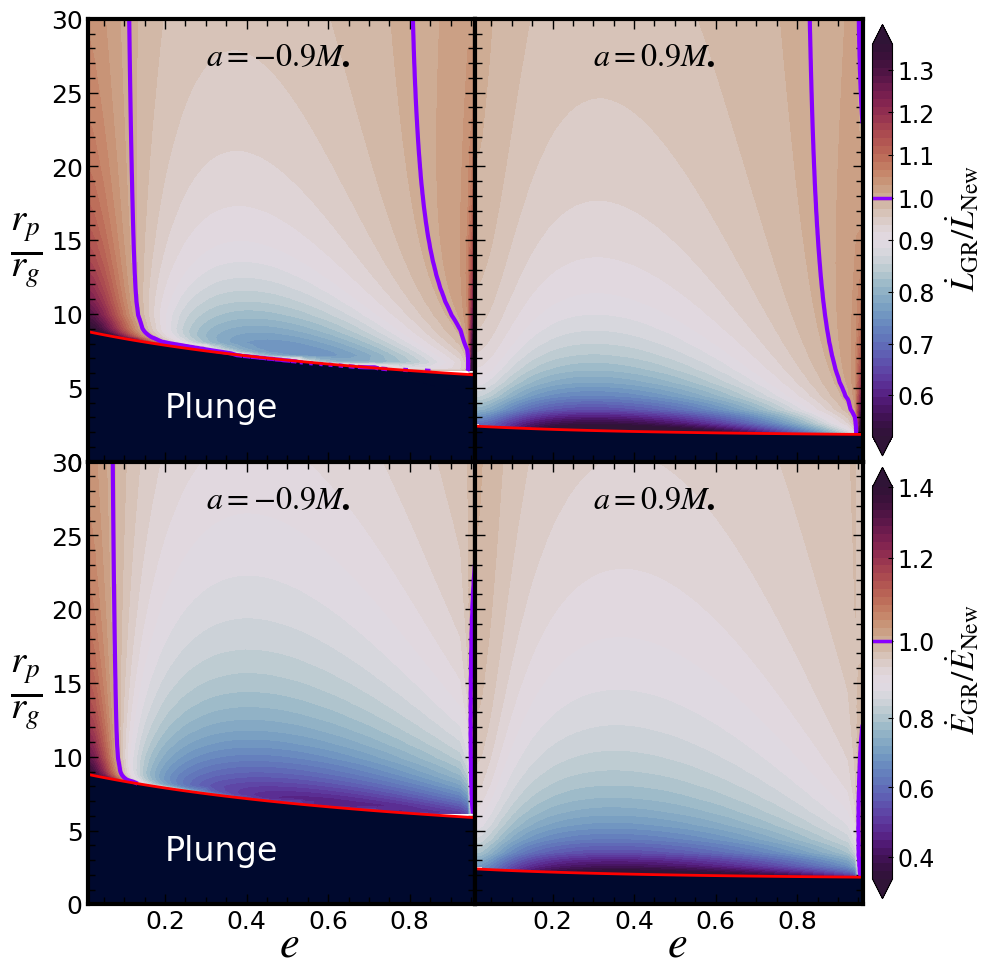

In [11]:
# --- Plotting ---
fig, axs = plt.subplots(2, 2, figsize=(10, 11.5), sharey=True)
ax3, ax4, ax1, ax2 = axs.flatten()  # Order: top-left=3, top-right=4, bottom-left=1, bottom-right=2

# Helper function to avoid code repetition
def plot_panel(ax, ZI, rp_plunge, is_dE=False):
    """Plot one panel with contourf, Z=1 contour, plunge curve, and fill."""
    cf = ax.contourf(
        XI, YI, ZI,
        levels=(levels_dE if is_dE else levels_dL),
        cmap='twilight_shifted',
        extend='both',
        norm=(norm_E if is_dE else norm_L)
    )
    # Add Z=1 contour (purple line)
    ax.contour(XI, YI, ZI, levels=[1], colors="#8800FF", linewidths=3)
    # Add 'Plunge' label on left panels
    if ax in [ax1, ax3]:
        ax.text(0.2, 3, 'Plunge', fontsize=24, color='white')
    # Plot plunge boundary curve (red)
    ax.plot(e_orbit_plunge_limit_line_table, rp_plunge, color='red', linewidth=2)
    # Shade unstable region below the curve
    ax.fill_between(e_orbit_plunge_limit_line_table, rp_plunge, 0, color="#00092EFE", alpha=1)
    # Set axis limits
    ax.set_ylim(0, 30)
    ax.set_xlim(0.01, 0.96)
    return cf

# Plot all four panels
cf1 = plot_panel(ax1, ZI_2_E, rp_plunge_limit_line_2 + 0.15, is_dE=True)   # dE, a=-0.9
cf2 = plot_panel(ax2, ZI_1_E, rp_plunge_limit_line_1 + 0.1, is_dE=True)    # dE, a=+0.9
cf3 = plot_panel(ax3, ZI_2_L, rp_plunge_limit_line_2 + 0.15, is_dE=False)  # dL, a=-0.9
cf4 = plot_panel(ax4, ZI_1_L, rp_plunge_limit_line_1 + 0.1, is_dE=False)   # dL, a=+0.9

# --- Labels and styling ---
# Axis labels
ax1.text(-0.18, 13.5, r'$\frac{r_{p}}{r_{g}}$', fontsize=40, color='black')
ax3.text(-0.18, 13.5, r'$\frac{r_{p}}{r_{g}}$', fontsize=40, color='black')
ax1.text(0.48, -3.5, r'$e$', fontsize=32, color='black')
ax2.text(0.48, -3.5, r'$e$', fontsize=32, color='black')

# Physical quantity labels (right side)
ax2.text(1.16, 12, r'$\dot{E}_{\mathrm{GR}}/\dot{E}_{\mathrm{New}}$', fontsize=24, rotation=90)
ax4.text(1.16, 12, r'$\dot{L}_{\mathrm{GR}}/\dot{L}_{\mathrm{New}}$', fontsize=24, rotation=90)

# Spin parameter labels
for ax, label in zip([ax1, ax2, ax3, ax4], 
                     [r'$a=-0.9M_{\bullet}$', r'$a=0.9M_{\bullet}$'] * 2):
    ax.text(0.3, 27, label, fontsize=23, color='black')

# Tick and spine styling
for ax in [ax1, ax2, ax3, ax4]:
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', width=1.0, length=7, labelsize=18, direction='in')
    ax.tick_params(axis='both', which='minor', width=1.0, length=5, direction='in')
    ax.tick_params(top=True, right=True, which='both', direction='in')
    for spine in ax.spines.values():
        spine.set_linewidth(3)

# Colorbars
# Top colorbar (for dL)
cbar_ax_top = fig.add_axes([0.91, 0.5, 0.02, 0.375])
cbar1 = fig.colorbar(cf4, cax=cbar_ax_top)
cbar1.set_ticks(np.arange(0.6, 1.31, 0.1))
cbar1.ax.tick_params(labelsize=17, direction='in')
cbar1.ax.plot([0, 1], [1, 1], color="#8800FF", linewidth=2.5)  # Highlight Z=1

# Bottom colorbar (for dE)
cbar_ax_bot = fig.add_axes([0.91, 0.115, 0.02, 0.375])
cbar2 = fig.colorbar(cf2, cax=cbar_ax_bot)
cbar2.set_ticks([0.4, 0.6, 0.8, 1.0, 1.2, 1.4])
cbar2.ax.tick_params(labelsize=17, direction='in')
cbar2.ax.plot([0, 1], [1, 1], color="#8800FF", linewidth=2.5)  # Highlight Z=1

# Font settings for math text
plt.rcParams["mathtext.fontset"] = "stix"
from matplotlib import font_manager as fm
prop = fm.FontProperties(family='DejaVu Sans', style='italic')
# Uncomment below if you want to add subscript 'g' manually
# for ax in [ax1, ax3]:
#     ax.text(-0.081, 12.35, 'g', fontproperties=prop, fontsize=16)

# Adjust layout
plt.subplots_adjust(wspace=0.0, hspace=0.0)

plt.show()